#### Step 1 导入相关包

In [1]:
import pandas as pd
import pickle

import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# 指定TSV文件路径
file_path = '../g_patent.tsv/g_patent.tsv'  # 替换为你的TSV文件路径

# 读取TSV文件
df = pd.read_csv(file_path, sep='\t')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_8072\1514124190.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep='\t')


In [3]:
# 提取年份（从patent_date中解析，假设格式为'YYYY-MM-DD'）
df['year'] = pd.to_datetime(df['patent_date'], errors='coerce').dt.year

# 去除年份为空的记录
valid_data = df[['patent_id', 'year']].dropna(subset=['year'])

# 转换年份为整数
valid_data['year'] = valid_data['year'].astype(int)

# 构建字典（确保patent_id唯一，若有重复取第一个出现的年份）
patent_year_dict = dict(valid_data.values)

#### Step 2 加载数据

In [2]:
# 指定TSV文件路径
file_path = '../g_us_patent_citation.tsv'  # 替换为你的TSV文件路径

# 读取TSV文件
df_citation = pd.read_csv(file_path, sep='\t',usecols=['patent_id', 'citation_patent_id'])

C:\Users\Administrator\AppData\Local\Temp\ipykernel_2848\132829706.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_citation = pd.read_csv(file_path, sep='\t',usecols=['patent_id', 'citation_patent_id'])


In [4]:
# 定义条件转换函数：尝试转为int，失败则保留str
def to_int_or_str(value):
    try:
        return int(value)
    except (ValueError, TypeError):
        return str(value)

# 应用转换到两列
df_citation['patent_id'] = df_citation['patent_id'].apply(to_int_or_str)
df_citation['citation_patent_id'] = df_citation['citation_patent_id'].apply(to_int_or_str)

In [9]:
def save_dicts(df, citing_path='./citations_result/citing_dict.pkl', ref_path='./citations_result/referenced_by_dict.pkl'):
    """保存citing_dict和referenced_by_dict到本地"""
    # 构建并保存被引专利->引用它的专利的映射
    citing_dict = df.groupby('citation_patent_id')['patent_id'].agg(set).to_dict()
    with open(citing_path, 'wb') as f:
        pickle.dump(citing_dict, f)
    print(f"citing_dict已保存至{citing_path}")
    
    # 构建并保存引用专利->它引用的专利的映射
    referenced_by_dict = df.groupby('patent_id')['citation_patent_id'].agg(set).to_dict()
    with open(ref_path, 'wb') as f:
        pickle.dump(referenced_by_dict, f)
    print(f"referenced_by_dict已保存至{ref_path}")

save_dicts(df_citation)  # 保存字典

citing_dict已保存至./citations_result/citing_dict.pkl
referenced_by_dict已保存至./citations_result/referenced_by_dict.pkl


#### 计算颠覆性 DI

In [4]:
from tqdm import tqdm

def calculate_d_from_dicts(citing_path='./citations_result/citing_dict.pkl', ref_path='./citations_result/referenced_by_dict.pkl'):
    """从本地加载字典，仅通过字典计算D指数（不依赖原始df）"""
    # 加载字典
    with open(citing_path, 'rb') as f:
        citing_dict = pickle.load(f)
    with open(ref_path, 'rb') as f:
        referenced_by_dict = pickle.load(f)
    print("字典加载完成")
    
    # 从两个字典中提取所有专利：citing_dict的键是被引专利，referenced_by_dict的键是引用专利
    # 两者的并集即为所有相关专利（覆盖引用与被引关系）
    all_patents = set(citing_dict.keys()).union(set(referenced_by_dict.keys()))
    results = []
    
    for patent in tqdm(all_patents):

        focal_year = patent_year_dict.get(patent)
        if focal_year is None:
            continue  # 无年份信息，无法计算n_k，跳过
        
        citing_patents = citing_dict.get(patent, set())
        p_references = referenced_by_dict.get(patent, set())

        # 过滤条件：必须至少有1个向前引用和1个向后引用
        if len(citing_patents) == 0 or len(p_references) == 0:
            continue  # 不满足条件则跳过
        
        # 计算n_i、n_j（同原逻辑）
        n_i, n_j = 0, 0
        for c in citing_patents:
            c_cites = referenced_by_dict.get(c, set())
            if c_cites & p_references:
                n_j += 1
            else:
                n_i += 1
        
        # 计算n_k（同原逻辑）
        ref_citing_all = set()
        for ref in p_references:
            ref_citing_all.update(citing_dict.get(ref, set()))
        
        
         # 3.2 修正n_k：仅保留“在焦点专利之后发表”且“不引用焦点专利”的成果
        n_k = 0
        for ref_citing_patent in ref_citing_all:
            # 条件1：该成果不引用焦点专利（即不在citing_patents中）
            if ref_citing_patent in citing_patents:
                continue
            # 条件2：该成果有年份信息，且年份>焦点专利年份（focal_year）
            ref_citing_year = patent_year_dict.get(ref_citing_patent)
            if ref_citing_year is not None and ref_citing_year > focal_year:
                n_k += 1
        
        # 计算D指数
        total = n_i + n_j + n_k
        d_index = (n_i - n_j) / total if total != 0 else 0.0
        results.append({'patent_id': patent, 'd_index': d_index})
    
    return pd.DataFrame(results)

#### 计算颠覆性 DI5

In [5]:
def calculate_cd5_from_dicts(citing_path='./citations_result/citing_dict.pkl', 
                             ref_path='./citations_result/referenced_by_dict.pkl',
                             time_window=5):
    """
    计算CD5指数（5年引文窗口），保留核心过滤逻辑：
    1. 过滤无年份信息的专利
    2. 过滤5年内无被引记录的专利（citing_patents筛选后为空）
    3. 过滤无参考文献的专利（p_references为空）
    
    参数：
    citing_path: citing_dict存储路径，格式：{被引专利ID: 引用该专利的专利ID集合}
    ref_path: referenced_by_dict存储路径，格式：{引用专利ID: 该专利引用的参考文献专利ID集合}
    time_window: 时间窗口年数，默认5（CD5）
    
    返回：
    pd.DataFrame: 包含patent_id（专利ID）和cd5_index（CD5指数）的结果表
    """
    # 1. 加载引用关系字典
    with open(citing_path, 'rb') as f:
        citing_dict = pickle.load(f)
    with open(ref_path, 'rb') as f:
        referenced_by_dict = pickle.load(f)
    print(f"字典加载完成，开始计算CD{time_window}指数（{time_window}年时间窗口）")
    
    # 2. 提取所有相关专利（覆盖引用与被引关系）
    all_patents = set(citing_dict.keys()).union(set(referenced_by_dict.keys()))
    results = []
    
    # 3. 遍历每个专利计算CD5指数
    for patent in tqdm(all_patents, desc=f"计算CD{time_window}指数进度"):
        # 3.1 获取焦点专利年份，无年份则跳过
        focal_year = patent_year_dict.get(patent)
        if focal_year is None:
            continue
        
        # 3.2 获取原始引用关系
        raw_citing_patents = citing_dict.get(patent, set())  # 所有引用该专利的专利
        p_references = referenced_by_dict.get(patent, set())  # 该专利的参考文献集合
        
        # 3.3 核心过滤逻辑1：无参考文献则跳过
        if len(p_references) == 0:
            continue
        
        # 3.4 筛选【5年时间窗口内】引用该专利的专利（T ≤ 引用年份 ≤ T+5）
        citing_patents = set()
        for c_patent in raw_citing_patents:
            c_year = patent_year_dict.get(c_patent)
            if c_year is not None and focal_year <= c_year <= focal_year + time_window:
                citing_patents.add(c_patent)
        
        # 3.5 核心过滤逻辑2：5年内无被引记录则跳过
        if len(citing_patents) == 0:
            continue
        
        # 3.6 计算n_i（仅引焦点专利，不引其参考文献）和n_j（同时引焦点专利+其参考文献）
        n_i, n_j = 0, 0
        for c in citing_patents:
            c_cites = referenced_by_dict.get(c, set())  # 该引用专利的参考文献集合
            if c_cites & p_references:  # 交集非空：同时引用了焦点专利和其参考文献
                n_j += 1
            else:  # 无交集：仅引用焦点专利，未引用其参考文献
                n_i += 1
        
        # 3.7 计算n_k（仅引焦点专利的参考文献、不引焦点专利、且在5年窗口内）
        ref_citing_all = set()
        for ref in p_references:
            # 收集所有引用该参考文献的专利
            ref_citing_all.update(citing_dict.get(ref, set()))
        
        n_k = 0
        for ref_citing_patent in ref_citing_all:
            # 条件1：不引用焦点专利（不在citing_patents中）
            if ref_citing_patent in citing_patents:
                continue
            # 条件2：有年份信息，且在焦点专利年份 < 引用年份 ≤ 焦点专利+5年
            ref_citing_year = patent_year_dict.get(ref_citing_patent)
            if (ref_citing_year is not None and 
                focal_year < ref_citing_year <= focal_year + time_window):
                n_k += 1
        
        # 3.8 计算CD5指数（避免除零错误）
        total = n_i + n_j + n_k
        cd5_index = (n_i - n_j) / total if total != 0 else 0.0
        
        # 3.9 保存结果
        results.append({
            'patent_id': patent,
            'cd5_index': cd5_index,
            # 'n_i': n_i, 
            # 'n_j': n_j,
            # 'n_k': n_k
        })
    
    # 4. 转换为DataFrame并返回
    result_df = pd.DataFrame(results)
    print(f"CD{time_window}指数计算完成，共处理有效专利 {len(result_df)} 个")
    return result_df

In [6]:
d_index_df = calculate_cd5_from_dicts()

字典加载完成，开始计算CD5指数（5年时间窗口）


计算CD5指数进度: 100%|██████████| 11040194/11040194 [46:46<00:00, 3933.77it/s] 


CD5指数计算完成，共处理有效专利 5245757 个


In [6]:
d_index_df

,patent_id,d_index
0,D602590,-0.009115
1,D385933,-0.009990
2,D872952,-0.043478
3,D525656,0.004963
4,D835034,-0.004651
...,...,...
6301435,D366759,0.018182
6301436,D676236,-0.043478
6301437,D770636,0.004717
6301438,D756961,-0.008299


In [11]:
d_index_df
d_index_df.to_csv('./citations_result/CD5_index.csv',index=False)

In [5]:
d_index_df.to_csv('./citations_result/DI_index.csv',index=False)

#### Step 3 加载颠覆性

In [2]:
d_index_df = pd.read_csv('./citations_result/DI_index.csv')

In [3]:
d_index_df

,patent_id,d_index
0,D580322,-0.369369
1,D620599,-0.107843
2,D633181,0.038710
3,D792235,-0.086667
4,D337815,-0.010638
...,...,...
6313901,D584754,0.010490
6313902,D251839,0.070175
6313903,D360478,0.089286
6313904,D819242,0.015317


In [4]:
d_index_df['patent_id'] = d_index_df['patent_id'].astype('str')

In [5]:
d_index_df

,patent_id,d_index
0,D580322,-0.369369
1,D620599,-0.107843
2,D633181,0.038710
3,D792235,-0.086667
4,D337815,-0.010638
...,...,...
6313901,D584754,0.010490
6313902,D251839,0.070175
6313903,D360478,0.089286
6313904,D819242,0.015317


In [8]:
df_citation = pd.read_csv('./citations_result/0_5_citations.csv')
df_citation.head()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11668\1037780568.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_citation = pd.read_csv('./citations_result/0_5_citations.csv')


,patent_id,patent_type,cites_0yr,cites_1yr,cites_2yr,cites_3yr,cites_4yr,cites_5yr,cites_10yr
0,10000000,utility,4,6,7,9,11,11,7
1,10000001,utility,0,0,0,0,0,0,0
2,10000002,utility,0,0,0,0,0,0,0
3,10000003,utility,1,1,2,2,2,2,2
4,10000004,utility,0,0,0,0,0,0,0


In [12]:
df_citation['patent_id'] = df_citation['patent_id'].astype('str')

In [13]:
df_citation_di = (
    df_citation
    .merge(
        d_index_df,
        left_on='patent_id',          # 被引专利
        right_on='patent_id',             # df_application 的专利
        how='left'                       
    )
)

In [15]:
df_citation_di = df_citation_di[df_citation_di['patent_type']=='utility']

In [16]:
df_citation_di

,patent_id,patent_type,cites_0yr,cites_1yr,cites_2yr,cites_3yr,cites_4yr,cites_5yr,cites_10yr,d_index
0,10000000,utility,4,6,7,9,11,11,7,0.041667
1,10000001,utility,0,0,0,0,0,0,0,0.000000
2,10000002,utility,0,0,0,0,0,0,0,0.000000
3,10000003,utility,1,1,2,2,2,2,2,0.034483
4,10000004,utility,0,0,0,0,0,0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...
9144791,RE31700,utility,0,0,0,0,0,0,0,0.428571
9144792,RE31701,utility,0,0,0,0,0,0,0,0.000000
9144795,RE31704,utility,0,0,0,0,0,0,0,0.090909
9147406,RE34357,utility,0,0,0,0,0,0,0,0.014742


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


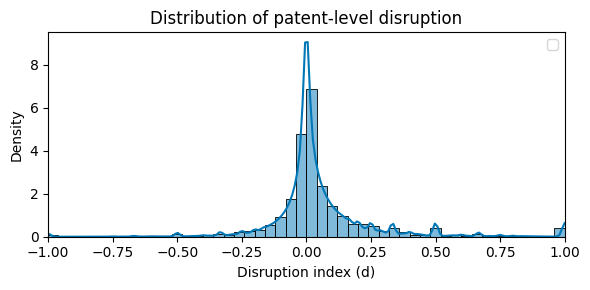

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,3))
sns.histplot(d_index_df['cd5_index'], bins=50, color='#0077b6', kde=True, stat='density')
plt.xlabel('Disruption index (d)')
plt.ylabel('Density')
plt.title('Distribution of patent-level disruption')
plt.xlim(-1,1)        # 如数值范围不同可自行调整
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
d_index_df

,patent_id,d_index
0,D602590,-0.009115
1,D385933,-0.009990
2,D872952,-0.043478
3,D525656,0.004963
4,D835034,-0.004651
...,...,...
6301435,D366759,0.018182
6301436,D676236,-0.043478
6301437,D770636,0.004717
6301438,D756961,-0.008299
